*Use this notebook to complete the sentence similarity and embedding visualization tasks.*


[nltk_data] Downloading package punkt to /Users/shiqishao/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/shiqishao/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


PyTorch Skip-Gram
0.7832 | The cat sat on the mat.
0.5504 | My shopping list includes milk and bread.
0.5089 | Programming requires logical thinking.
0.4319 | A dog is playing in the yard.
0.4101 | I need to buy groceries today.
0.4060 | Canines enjoy outdoor activities.
0.3431 | The weather is beautiful today.
0.1420 | The feline was resting on the rug.
Gensim Word2Vec Trained
0.6952 | The cat sat on the mat.
0.5783 | A dog is playing in the yard.
0.5002 | The feline was resting on the rug.
0.4975 | The weather is beautiful today.
0.4642 | My shopping list includes milk and bread.
0.2062 | I need to buy groceries today.
0.0743 | Canines enjoy outdoor activities.
0.0699 | Programming requires logical thinking.
GoogleNews Word2Vec
0.7794 | The feline was resting on the rug.
0.7369 | The cat sat on the mat.
0.6483 | A dog is playing in the yard.
0.4970 | My shopping list includes milk and bread.
0.4310 | The weather is beautiful today.
0.4281 | Canines enjoy outdoor activities.
0.3718 | 

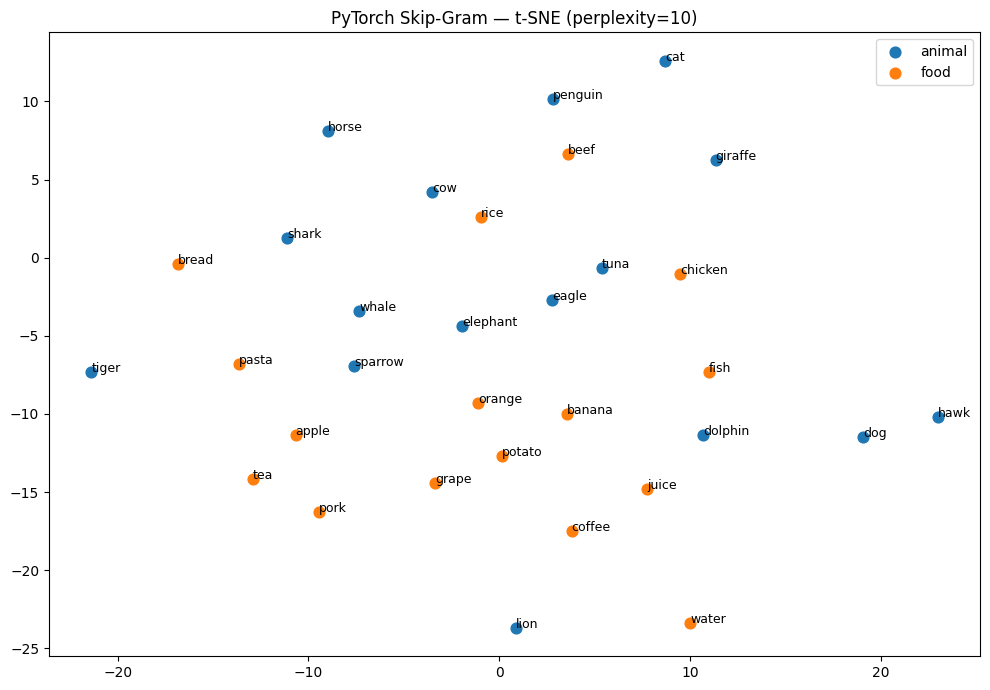

/Users/shiqishao/Desktop/2025-winter/STAT-359/stat359/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shiqishao/Desktop/2025-winter/STAT-359/stat359/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


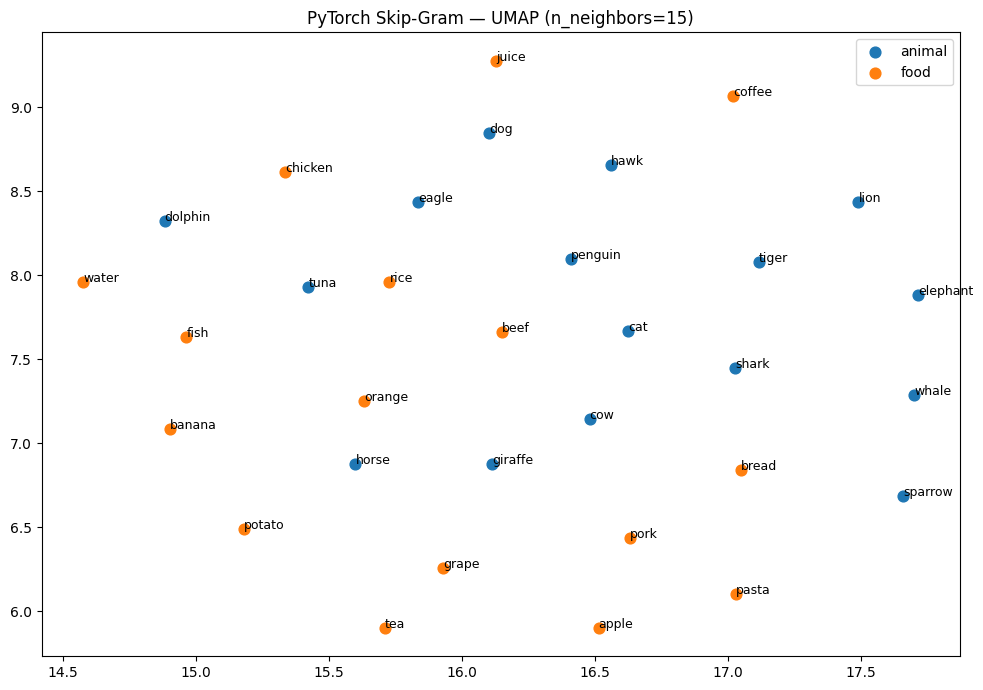


 Visualization | Gensim Word2Vec Trained 


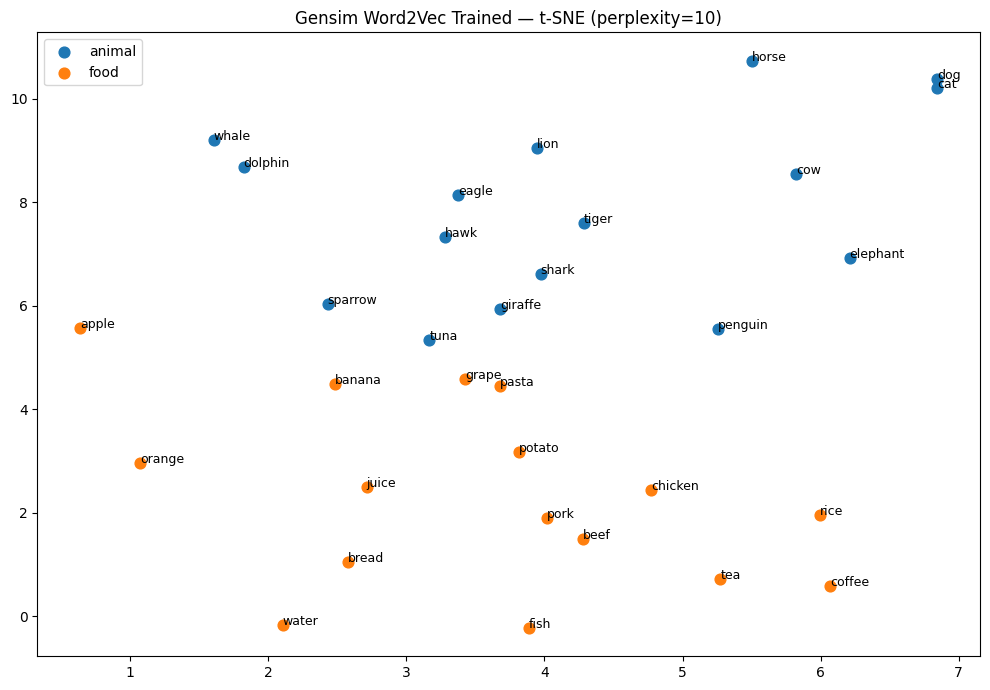

/Users/shiqishao/Desktop/2025-winter/STAT-359/stat359/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shiqishao/Desktop/2025-winter/STAT-359/stat359/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


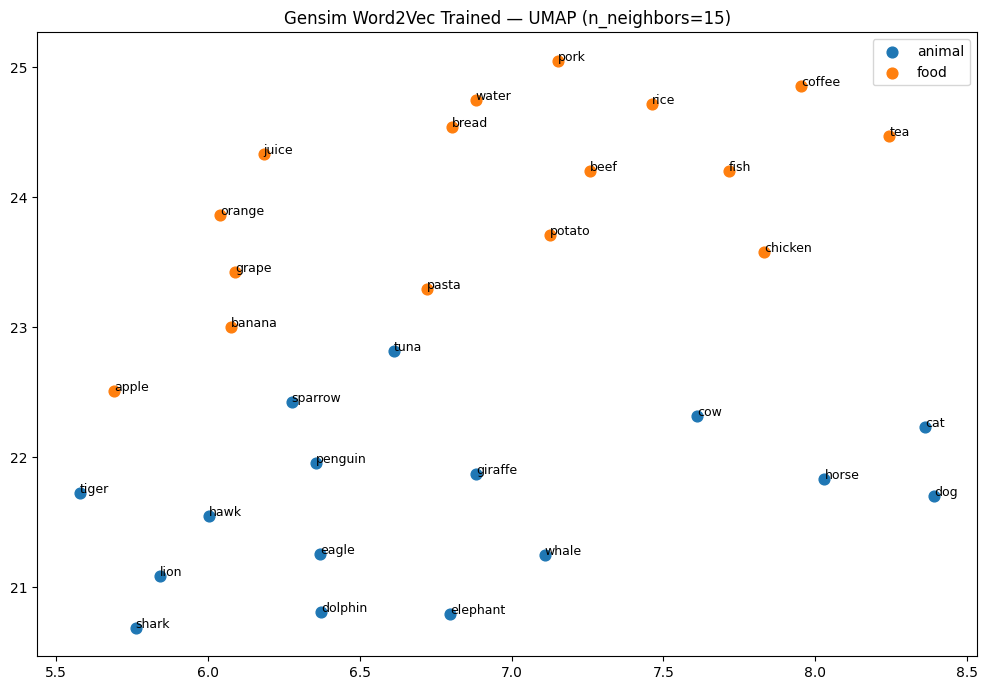


 Visualization | GoogleNews Word2Vec 


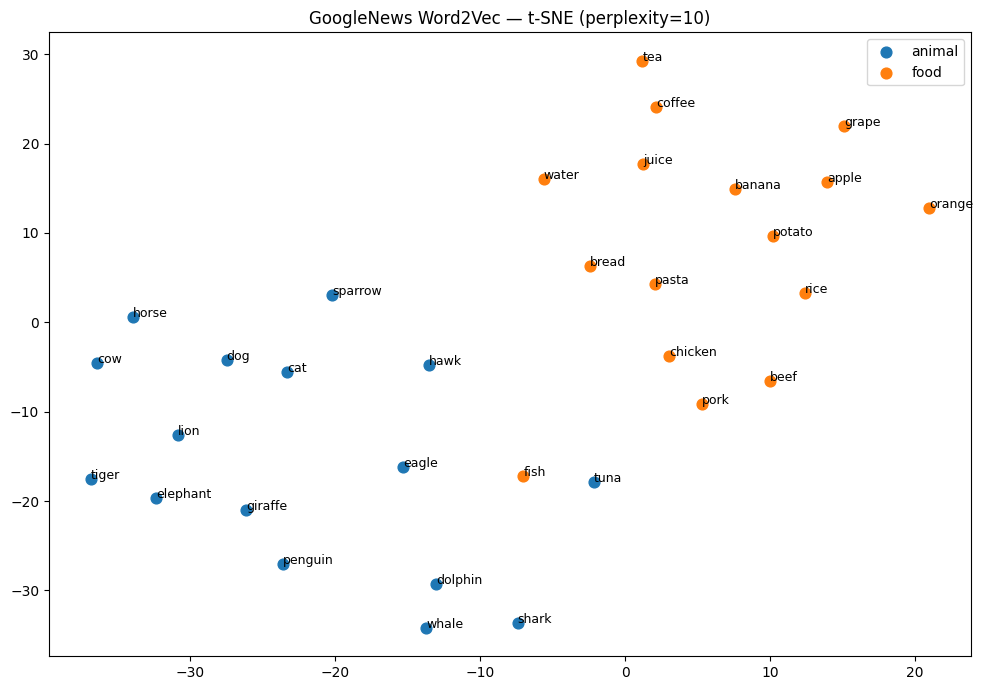

/Users/shiqishao/Desktop/2025-winter/STAT-359/stat359/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shiqishao/Desktop/2025-winter/STAT-359/stat359/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


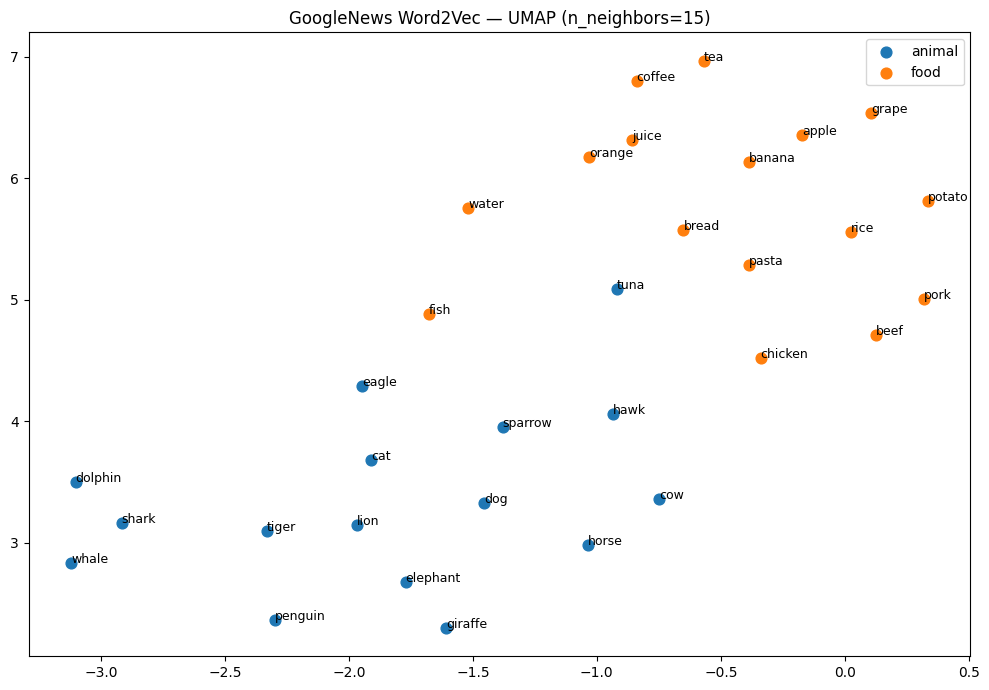


 Visualization | FastText Subword 


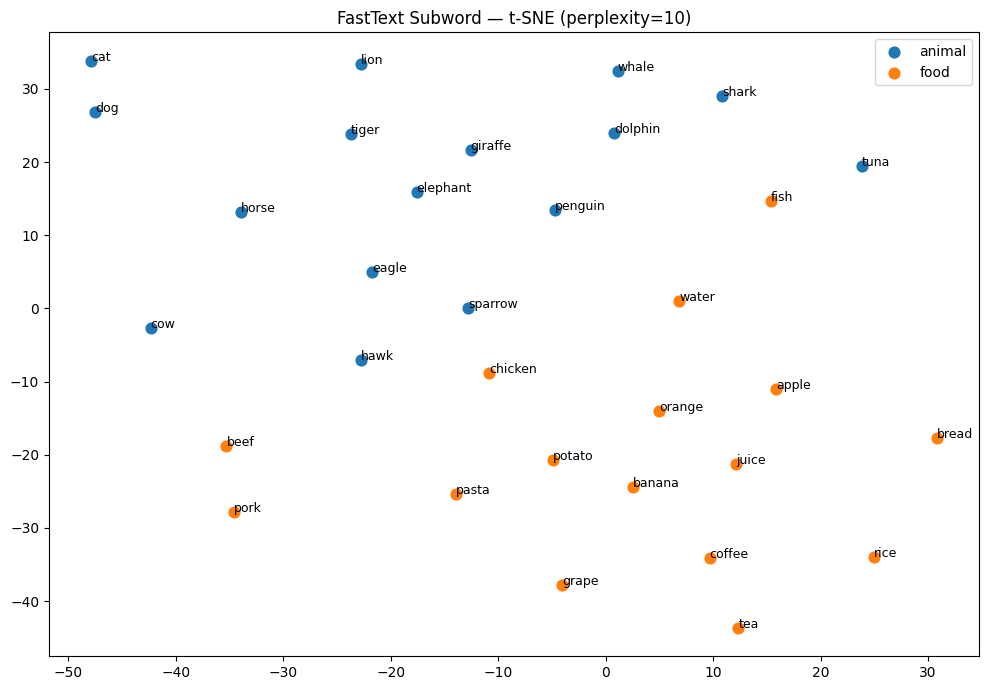

/Users/shiqishao/Desktop/2025-winter/STAT-359/stat359/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shiqishao/Desktop/2025-winter/STAT-359/stat359/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


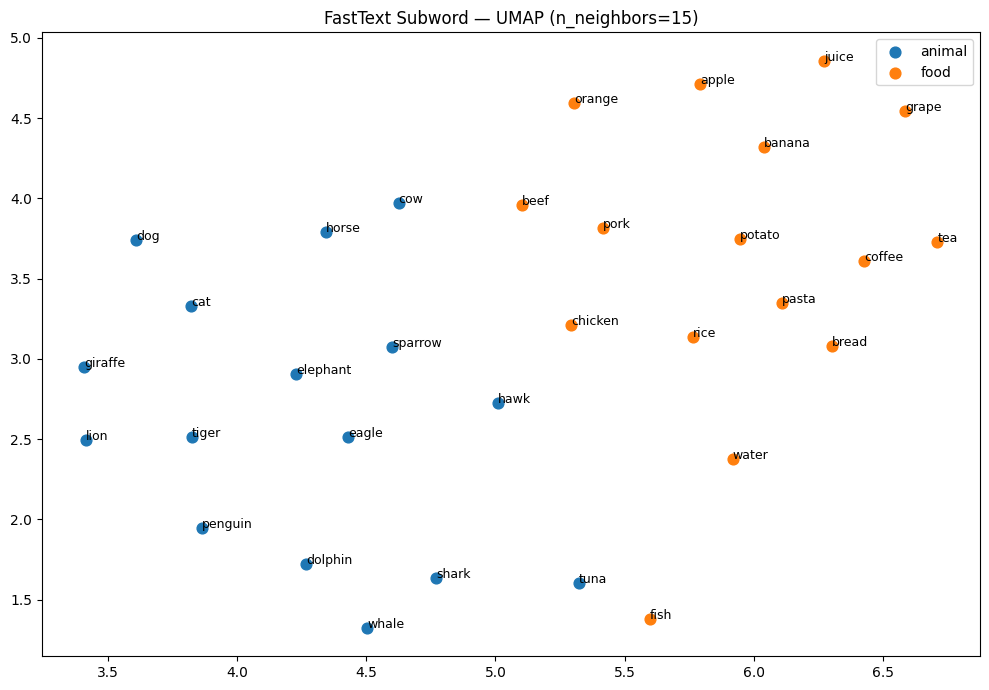

In [1]:
import pickle
import numpy as np

import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
from nltk.tokenize import word_tokenize

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import umap

from gensim.models import Word2Vec, KeyedVectors

def tokenize_text(text: str):
    return word_tokenize(text.lower())

with open("word2vec_embeddings.pkl", "rb") as f:
    pt_data = pickle.load(f)

pt_embeddings = pt_data["embeddings"]
pt_word2idx = pt_data["word2idx"]
pt_idx2word = pt_data["idx2word"]

def get_vec_pytorch(word: str):
    idx = pt_word2idx.get(word)
    if idx is None:
        return None
    return pt_embeddings[idx]

gensim_w2v = Word2Vec.load("word2vec_text8_gensim.model")

def get_vec_gensim_trained(word: str):
    return gensim_w2v.wv[word] if word in gensim_w2v.wv else None

google_w2v = KeyedVectors.load("word2vec-google-news-300.model")

def get_vec_google(word: str):
    return google_w2v[word] if word in google_w2v else None

fasttext_kv = KeyedVectors.load("fasttext-wiki-news-subwords-300.model")

def get_vec_fasttext(word: str):
    return fasttext_kv[word] if word in fasttext_kv else None

SOURCES = [
    ("PyTorch Skip-Gram", get_vec_pytorch),
    ("Gensim Word2Vec Trained", get_vec_gensim_trained),
    ("GoogleNews Word2Vec", get_vec_google),
    ("FastText Subword", get_vec_fasttext),
]

def sentence_embedding(sentence: str, get_vec_fn):
    tokens = tokenize_text(sentence)
    vecs = []
    for t in tokens:
        v = get_vec_fn(t)
        if v is not None:
            vecs.append(v)
    if len(vecs) == 0:
        return None
    return np.mean(np.vstack(vecs), axis=0)

def cosine_sim(a, b) -> float:
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

sentences = [
    "The cat sat on the mat.",
    "A dog is playing in the yard.",
    "I need to buy groceries today.",
    "The feline was resting on the rug.",
    "Canines enjoy outdoor activities.",
    "My shopping list includes milk and bread.",
    "The weather is beautiful today.",
    "Programming requires logical thinking."
]
    
query = "My pet cat is sleeping on the carpet."

def run_sentence_similarity(name, get_vec_fn):
    print(name)
    q = sentence_embedding(query, get_vec_fn)

    results = []
    for s in sentences:
        v = sentence_embedding(s, get_vec_fn)
        sim = cosine_sim(q, v)
        results.append((s, sim))

    results.sort(key=lambda x: -x[1])

    for s, sim in results:
        sim_str = f"{sim:.4f}"
        print(sim_str, "|", s)

animals = [
    'dog', 'cat', 'horse', 'cow',
    'lion', 'tiger', 'elephant', 'giraffe',
    'eagle', 'hawk', 'sparrow', 'penguin',
    'shark', 'whale', 'dolphin', 'tuna'
]

foods = [
    'apple', 'orange', 'banana', 'grape',
    'bread', 'pasta', 'rice', 'potato',
    'chicken', 'beef', 'pork', 'fish',
    'coffee', 'tea', 'juice', 'water'
]

def collect_vectors(words, get_vec_fn):
    kept_words, vecs = [], []
    for w in words:
        v = get_vec_fn(w)
        kept_words.append(w)
        vecs.append(v)
    return kept_words, np.vstack(vecs)

def prepare_category_vectors(get_vec_fn):
    a_words, a_vecs = collect_vectors(animals, get_vec_fn)
    f_words, f_vecs = collect_vectors(foods, get_vec_fn)
    words = a_words + f_words
    X = np.vstack([a_vecs, f_vecs])
    labels = (["animal"] * len(a_words)) + (["food"] * len(f_words))
    return words, X, labels

def plot_2d(points, words, labels, title):
    plt.figure(figsize=(10, 7))

    for cat, color in [("animal", "tab:blue"), ("food", "tab:orange")]:
        idx = [i for i, y in enumerate(labels) if y == cat]
        plt.scatter(points[idx, 0], points[idx, 1],
                    label=cat, s=60, c=color)

    for i, w in enumerate(words):
        plt.text(points[i, 0], points[i, 1], w, fontsize=9)

    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def run_tsne_umap(name, get_vec_fn,
                  tsne_perplexity=20,
                  umap_n_neighbors=15,
                  random_state=42):
    words, X, labels = prepare_category_vectors(get_vec_fn)

    print(f"\n Visualization | {name} ")

    perplexity = min(tsne_perplexity, max(2, len(words) // 3))
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        early_exaggeration=12.0,
        random_state=random_state
    )
    Z_tsne = tsne.fit_transform(X)
    plot_2d(Z_tsne, words, labels, f"{name} — t-SNE (perplexity={perplexity})")

    n_neighbors = min(umap_n_neighbors, len(words) - 1)
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=0.1,
        random_state=random_state
    )
    Z_umap = reducer.fit_transform(X)
    plot_2d(Z_umap, words, labels, f"{name} — UMAP (n_neighbors={n_neighbors})")


def main():
    for name, fn in SOURCES:
        run_sentence_similarity(name, fn)

    for name, fn in SOURCES:
        run_tsne_umap(name, fn)

if __name__ == "__main__":
    main()







(a) FastText has the best performance at capturing sentence meaning. It gives steady and high cosine similarity to the related sentence. And the model trained on google news performed the second best. Two models trained on Text8 could not capture the meaning very well(could not tell well that cat and feline are close).

(b) The pretrained embeddings are obviously better than mine. In the visualization part, the pretrained models could tell apart two categories very well, while mine couldn't.  Also, in the part of capturing the sentence meaning, pretrained models also perform better.

(c) The reason cause might be the corpus. The model trained on google news and the fasttext model are trained on larger and more comprehensive corpus, while mine is trained on Text8. 
The second factor is the model itself. Fasttext could capture the meaning of subword, which makes it easier to capture the meaning of words with low frequency and transformation.
The third factor is the details in training. Different negative samples, learning rate, initialization and other settings could affect the model.
The last possible reason is that the evaluation is not comprehensive. The model I trained might perform better in other context.

## AI Use Disclosure (Required)

If you used any AI-enabled tools (e.g., ChatGPT, GitHub Copilot, Claude, or other LLM assistants) while working on this assignment, you must disclose that use here. The goal is transparency-not punishment.

In your disclosure, briefly include:
- **Tool(s) used:** (name + version if known)
- **How you used them:** (e.g., concept explanation, debugging, drafting code, rewriting text)
- **What you verified yourself:** (e.g., reran the notebook, checked outputs/plots, checked shapes, read documentation)
- **What you did *not* use AI for (if applicable):** (optional)

You are responsible for the correctness of your submission, even if AI suggested code or explanations.

I used GPT5.2. I used it for the stucture of building a model(function names, input and output) and the evaluation, as I haven't learnt about t-SNE and UMAP before. I read related documentation and modified them according to my understanding.